# Bài tập Buổi 5 — Pipeline Machine Learning: EDA & Tiền xử lý trên Titanic

**Khóa học hè 2026 — Python & Machine Learning · ML IoT Lab, HCMUT**

---

## Bối cảnh

Bạn vừa nhận được dataset **Titanic** — danh sách hành khách và việc họ có sống sót sau thảm họa hay không.
Nhiệm vụ của bạn **không phải** huấn luyện mô hình, mà là hoàn thành **hai bước đầu và quan trọng nhất** của một dự án Machine Learning:

> **Khám phá dữ liệu (EDA) → Tiền xử lý dữ liệu.**

Đây là phần chiếm ~70–90% công sức thực tế của một dự án ML. Một mô hình mạnh không thể cứu một bộ dữ liệu kém chất lượng.

## Mục tiêu bài tập

Sau khi hoàn thành, bạn sẽ chứng minh được rằng mình có thể:

1. Thực hiện **EDA đầy đủ** trên một dataset thực tế: kiểm tra cấu trúc, giá trị thiếu, outlier, phân phối và tương quan.
2. **Trực quan hóa** dữ liệu và **rút ra nhận xét có căn cứ** (không chỉ vẽ hình cho đẹp).
3. Áp dụng **đúng kỹ thuật tiền xử lý** cho từng loại dữ liệu: xử lý missing, encoding, scaling.
4. Chia tập và xây pipeline tiền xử lý **không rò rỉ dữ liệu (data leakage)**.
5. Viết **nhận xét tổng hợp** về dữ liệu như một data analyst thực thụ.

## Yêu cầu nộp bài

- Hoàn thiện notebook này (điền vào tất cả các ô `# TODO` và các phần *"Trả lời:"*).
- Notebook phải **chạy được từ trên xuống dưới không lỗi** (Kernel → Restart & Run All).
- Nộp qua **GitHub**: tải repo mẫu → đưa lên repo cá nhân → làm bài và nộp trên đó.

## Tiêu chí chấm (10 điểm)

| Nội dung | Điểm |
|---|---|
| EDA đầy đủ (shape/info/missing/outlier) | 2.0 |
| Trực quan hóa + nhận xét cho mỗi biểu đồ | 2.0 |
| Xử lý missing & outlier hợp lý, có giải thích | 1.5 |
| Encoding & scaling đúng loại biến | 1.5 |
| Chia tập & tiền xử lý **không leakage** | 1.5 |
| Nhận xét tổng hợp về dữ liệu | 1.5 |

> **Lưu ý về liêm chính học thuật:** được tham khảo tài liệu, nhưng phải **tự viết code và tự hiểu**. Phần nhận xét phải là quan sát của chính bạn từ dữ liệu.

---


## 0. Chuẩn bị môi trường

Ô này đã viết sẵn — chạy để nạp thư viện. Nếu thiếu thư viện, cài bằng `pip install pandas numpy matplotlib seaborn scikit-learn`.

In [15]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, RobustScaler, StandardScaler

pd.set_option("display.max_columns", None)
sns.set_theme(style="whitegrid")
np.random.seed(42)          # cố định ngẫu nhiên -> kết quả tái lập được
print("Sẵn sàng.")

Sẵn sàng.


## 1. Tải dữ liệu (đã cho)

Ô này đã viết sẵn. Dữ liệu được tải từ `seaborn`, có fallback tải từ Internet nếu cần.

In [16]:
try:
    df = sns.load_dataset("titanic")
    print("Đã tải từ seaborn.")
except Exception:
    url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"
    df = pd.read_csv(url)
    df.columns = [c.lower() for c in df.columns]
    print("Đã tải từ URL.")
df.head()

Đã tải từ seaborn.


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


---
## Task 1 — Loại bỏ cột rò rỉ nhãn (data leakage) và cột dư thừa

### Mục đích
Trên slide đã học: **data leakage** là khi thông tin không được phép "rò" vào mô hình, khiến kết quả đẹp trên giấy nhưng vô dụng thực tế. Bản Titanic của seaborn chứa sẵn nhiều cột **rò rỉ nhãn** hoặc **trùng lặp**:

- `alive` (yes/no) — chính là `survived` viết bằng chữ ⇒ **rò rỉ target trực tiếp**. Để lại là mô hình "gian lận".
- `who`, `adult_male`, `class` — được suy ra từ `sex`, `age`, `pclass` (trùng thông tin).
- `deck` — thiếu quá nhiều (~77%).
- `embark_town` — trùng `embarked`; `alone` — suy ra từ `sibsp` + `parch`.

### Yêu cầu
1. In ra danh sách cột và tỷ lệ missing của **toàn bộ** dataframe (để thấy `deck` thiếu bao nhiêu).
2. Loại bỏ các cột rò rỉ / dư thừa ở trên, chỉ giữ lại:
   `survived, pclass, sex, age, sibsp, parch, fare, embarked`.
3. **Trả lời** (markdown ô dưới): vì sao để lại cột `alive` sẽ khiến mô hình đạt accuracy ~100% mà không thực sự học được gì?

### Gợi ý
- `df.isnull().mean()` cho tỷ lệ thiếu theo cột.
- `df.drop(columns=[...])` để bỏ cột.

In [17]:
# TODO 1a: in tỷ lệ missing của tất cả các cột
print("Danh sách cột:")
print(list(df.columns))

print("\nTỷ lệ missing (%):")
print((df.isnull().mean() * 100).round(2))

# TODO 1b: bỏ các cột rò rỉ/dư thừa, gán lại vào biến df
cot_can_giu = [
    "survived",
    "pclass",
    "sex",
    "age",
    "sibsp",
    "parch",
    "fare",
    "embarked"
]
leaky = [col for col in df.columns if col not in cot_can_giu] # điền danh sách cột cần bỏ (chỉ những cột có trong df)
# df = df.drop(columns=...)
df = df.drop(columns=leaky)
# print("Các cột còn lại:", list(df.columns))
print("Các cột đã bỏ:", leaky)
print("Các cột còn lại:", list(df.columns))     



Danh sách cột:
['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare', 'embarked', 'class', 'who', 'adult_male', 'deck', 'embark_town', 'alive', 'alone']

Tỷ lệ missing (%):
survived        0.00
pclass          0.00
sex             0.00
age            19.87
sibsp           0.00
parch           0.00
fare            0.00
embarked        0.22
class           0.00
who             0.00
adult_male      0.00
deck           77.22
embark_town     0.22
alive           0.00
alone           0.00
dtype: float64
Các cột đã bỏ: ['class', 'who', 'adult_male', 'deck', 'embark_town', 'alive', 'alone']
Các cột còn lại: ['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare', 'embarked']


**Trả lời 1c (vì sao `alive` gây rò rỉ target):**

Theo em cột alive có nội dung tương đương hoàn toàn với cột mục tiêu survived. Trong đó, alive = yes tương ứng với survived = 1 và alive = no tương ứng với survived = 0.

Nếu giữ lại cột alive, mô hình chỉ cần đọc trực tiếp đáp án từ cột này nên có thể đạt accuracy gần 100%. Tuy nhiên, mô hình không thật sự học được mối quan hệ giữa các đặc trưng của hành khách và khả năng sống sót. Khi dự đoán dữ liệu mới, cột alive chưa tồn tại nên mô hình sẽ không có giá trị thực tế.

---
## Task 2 — Quan sát tổng quan

### Mục đích
Trước khi phân tích sâu, phải nắm được "hình dạng" của dữ liệu: bao nhiêu mẫu, bao nhiêu đặc trưng, kiểu dữ liệu từng cột, và thống kê cơ bản. Đây là bước đầu tiên của mọi EDA.

### Yêu cầu
1. In **số dòng và số cột**; nêu rõ đâu là **biến mục tiêu (target)**.
2. Dùng `df.info()` để xem kiểu dữ liệu và số giá trị non-null.
3. Dùng `df.describe()` cho biến số và `df.describe(include="object")` (hoặc `"category"`) cho biến phân loại.
4. **Trả lời:** cột nào là biến **số**, cột nào là biến **phân loại**?

In [18]:
# TODO 2: shape, info, describe
print("Số dòng:", df.shape[0])
print("Số cột:", df.shape[1])
print("Biến mục tiêu: survived")

print("\nThông tin dataframe:")
df.info()

print("\nThống kê biến số:")
print(df.describe())

print("\nThống kê biến phân loại:")
include=["str", "category"]

Số dòng: 891
Số cột: 8
Biến mục tiêu: survived

Thông tin dataframe:
<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 8 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   survived  891 non-null    int64  
 1   pclass    891 non-null    int64  
 2   sex       891 non-null    str    
 3   age       714 non-null    float64
 4   sibsp     891 non-null    int64  
 5   parch     891 non-null    int64  
 6   fare      891 non-null    float64
 7   embarked  889 non-null    str    
dtypes: float64(2), int64(4), str(2)
memory usage: 55.8 KB

Thống kê biến số:
         survived      pclass         age       sibsp       parch        fare
count  891.000000  891.000000  714.000000  891.000000  891.000000  891.000000
mean     0.383838    2.308642   29.699118    0.523008    0.381594   32.204208
std      0.486592    0.836071   14.526497    1.102743    0.806057   49.693429
min      0.000000    1.000000    0.420000    0.000000    0

**Trả lời 2 (biến số vs biến phân loại):**

Các biến số gồm:

survived: biến mục tiêu nhị phân, nhận giá trị 0 hoặc 1.
age: độ tuổi của hành khách.
sibsp: số anh chị em hoặc vợ/chồng đi cùng.
parch: số cha mẹ hoặc con cái đi cùng.
fare: giá vé.
pclass: được lưu dưới dạng số nhưng thực chất là biến thứ tự, với hạng 1 cao hơn hạng 2 và hạng 3.

Các biến phân loại gồm:

sex: giới tính của hành khách.
embarked: cảng lên tàu, gồm C, Q và S.

---
## Task 3 — Missing Value: thống kê & đề xuất cách xử lý

### Mục đích
Mô hình học máy **không nhận trực tiếp giá trị NaN**. Nhưng cách xử lý phụ thuộc **tỷ lệ thiếu** và **vai trò của cột** — không có một cách đúng cho mọi trường hợp.

### Yêu cầu
1. Lập bảng: mỗi cột còn missing → **số lượng** và **phần trăm** thiếu.
2. Với **từng cột** còn thiếu, **đề xuất** cách xử lý và **giải thích ngắn gọn** (xóa / điền mean / điền median / điền mode / KNN...).

### Gợi ý
- Nhắc lại từ slide: `median` bền vững hơn `mean` khi có outlier; cột thiếu quá nhiều (>~60–70%) thường nên **bỏ**; biến phân loại thường điền **mode**.

In [19]:
# TODO 3: bảng missing (count + %)
missing_count = df.isnull().sum()
missing_percent = df.isnull().mean() * 100

bang_missing = pd.DataFrame({
    "Số lượng thiếu": missing_count,
    "Phần trăm thiếu (%)": missing_percent.round(2)
})

# Chỉ giữ lại các cột thật sự có missing
bang_missing = bang_missing[
    bang_missing["Số lượng thiếu"] > 0
]

# Sắp xếp cột thiếu nhiều nhất lên trước
bang_missing = bang_missing.sort_values(
    by="Phần trăm thiếu (%)",
    ascending=False
)

bang_missing

,Số lượng thiếu,Phần trăm thiếu (%)
age,177,19.87
embarked,2,0.22


**Trả lời 3 (đề xuất xử lý cho từng cột thiếu):**

| Cột | % thiếu | Cách xử lý đề xuất | Lý do |

|age|19.87%|Điền bằng median của tập train|Tỷ lệ thiếu chưa quá lớn nên không nên xóa cột hoặc xóa toàn bộ các dòng. Median ít bị ảnh hưởng bởi các hành khách có tuổi quá cao hoặc quá thấp.|

|embarked| 0.22% | Điền bằng mode của tập train | Đây là biến phân loại và chỉ thiếu 2 dòng. Mode là cảng xuất hiện nhiều nhất nên phù hợp để điền giá trị thiếu. |

---
## Task 4 — Phát hiện Outlier & **ra quyết định**

### Mục đích
Outlier có thể là **lỗi nhập liệu** (cần xử lý) hoặc **hiện tượng thật** (cần giữ). Phát hiện thôi chưa đủ — một analyst giỏi phải **quyết định** làm gì và giải thích được.

### Yêu cầu
1. Trên hai cột `age` và `fare`, đếm số outlier bằng **cả hai** phương pháp: **IQR** và **Z-score** (ngưỡng |z| > 3).
2. **Trả lời:** với các outlier của `fare`, bạn **giữ lại hay loại bỏ**? Vì sao? (gợi ý: nghĩ xem vé đắt bất thường là lỗi hay là vé hạng nhất có thật).

### Gợi ý
- IQR: outlier là điểm ngoài khoảng `[Q1 - 1.5*IQR, Q3 + 1.5*IQR]`.
- Z-score: `from scipy import stats; np.abs(stats.zscore(series.dropna()))`.

In [20]:
# TODO 4: đếm outlier theo IQR và Z-score cho 'age' và 'fare'
def dem_outlier_iqr(s):
    # Bỏ các giá trị NaN trước khi tính
    s = s.dropna()

    q1 = s.quantile(0.25)
    q3 = s.quantile(0.75)
    iqr = q3 - q1

    can_duoi = q1 - 1.5 * iqr
    can_tren = q3 + 1.5 * iqr

    outlier = (s < can_duoi) | (s > can_tren)

    # Trả về số lượng giá trị nằm ngoài hai cận
    return outlier.sum()

def dem_outlier_zscore(s, nguong=3.0):
    # Bỏ các giá trị NaN trước khi tính
    s = s.dropna()

    z_score = np.abs(stats.zscore(s))

    # Đếm số giá trị có |z-score| lớn hơn ngưỡng
    return (z_score > nguong).sum()

# for col in ["age", "fare"]:
for col in ["age", "fare"]:
    print(f"{col}:")
    print("  Outlier theo IQR:", dem_outlier_iqr(df[col]))
    print("  Outlier theo Z-score:", dem_outlier_zscore(df[col]))

age:
  Outlier theo IQR: 11
  Outlier theo Z-score: 2
fare:
  Outlier theo IQR: 116
  Outlier theo Z-score: 20


**Trả lời 4 (quyết định với outlier của `fare`):**

Theo phương pháp IQR, cột fare có 116 outlier, trong khi phương pháp Z-score phát hiện 20 outlier. Hai kết quả khác nhau vì phân phối fare lệch phải mạnh, làm cho mean và standard deviation dùng trong Z-score bị ảnh hưởng bởi các giá trị lớn.

Em quyết định giữ lại các outlier của fare vì giá vé cao có thể là dữ liệu thật của hành khách mua vé hạng nhất hoặc mua vé cho nhiều người, không nhất thiết là lỗi nhập liệu. Tuy nhiên, các giá trị này có thể ảnh hưởng đến quá trình scaling nên em sử dụng RobustScaler, vì phương pháp này dựa trên median và IQR nên ít bị ảnh hưởng bởi outlier hơn StandardScaler.

---
## Task 5 — Trực quan hóa & nhận xét

### Mục đích
EDA là môn học về **nhìn** dữ liệu. Mỗi biểu đồ phải trả lời một câu hỏi và **đi kèm một nhận xét**. Vẽ mà không nhận xét thì không tính điểm.

### Yêu cầu — vẽ tối thiểu 4 loại biểu đồ, mỗi biểu đồ 1–2 câu nhận xét:
1. **Univariate — Histogram**: phân phối của `age` và `fare`. (Nhận xét: có lệch không? lệch trái hay phải?)
2. **Univariate — Boxplot**: `fare` theo nhóm `survived` hoặc `pclass`. (Nhận xét: outlier, trung vị.)
3. **Bivariate — Bar/Barplot**: **tỷ lệ sống sót** theo `sex` và theo `pclass`. (Nhận xét: nhóm nào sống nhiều hơn, chênh bao nhiêu %?)
4. **Multivariate — Heatmap**: ma trận tương quan giữa các biến số. (Nhận xét: cặp biến nào tương quan mạnh?)

### Gợi ý
- `sns.histplot`, `sns.boxplot`, `sns.barplot(data=df, x="sex", y="survived")` (barplot tự tính trung bình = tỷ lệ sống sót), `sns.heatmap(df.select_dtypes("number").corr(), annot=True)`.

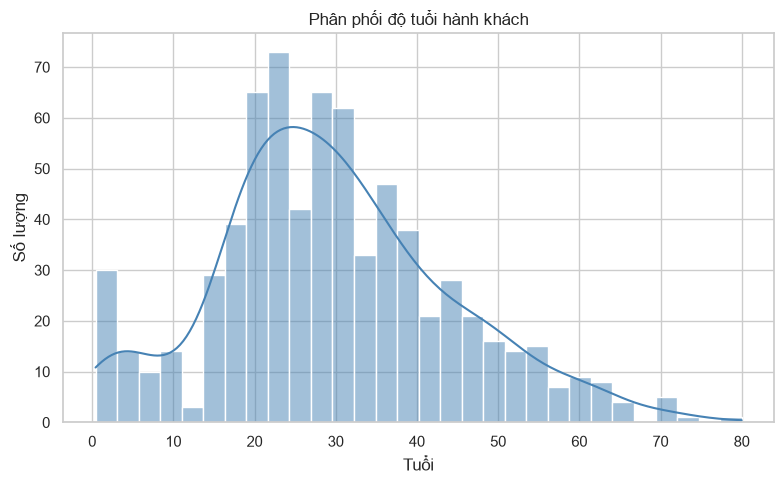

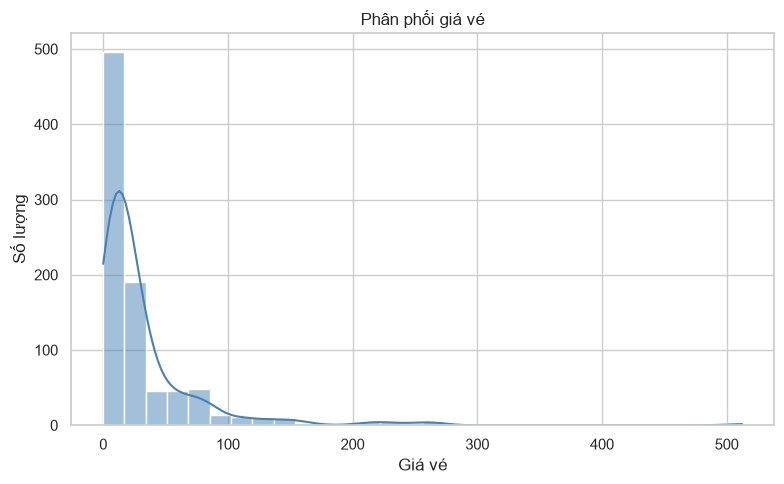

Độ lệch của age: 0.389
Độ lệch của fare: 4.787


In [21]:
# TODO 5a: Histogram age & fare
# Histogram của age
plt.figure(figsize=(8, 5))

sns.histplot(
    data=df,
    x="age",
    bins=30,
    kde=True,
    color="steelblue"
)

plt.title("Phân phối độ tuổi hành khách")
plt.xlabel("Tuổi")
plt.ylabel("Số lượng")
plt.tight_layout()
plt.show()

# Histogram của fare
plt.figure(figsize=(8, 5))

sns.histplot(
    data=df,
    x="fare",
    bins=30,
    kde=True,
    color="steelblue"
)

plt.title("Phân phối giá vé")
plt.xlabel("Giá vé")
plt.ylabel("Số lượng")
plt.tight_layout()
plt.show()


print("Độ lệch của age:", round(df["age"].skew(), 3))
print("Độ lệch của fare:", round(df["fare"].skew(), 3))

Trung vị giá vé theo survived:
survived
0    10.5
1    26.0
Name: fare, dtype: float64


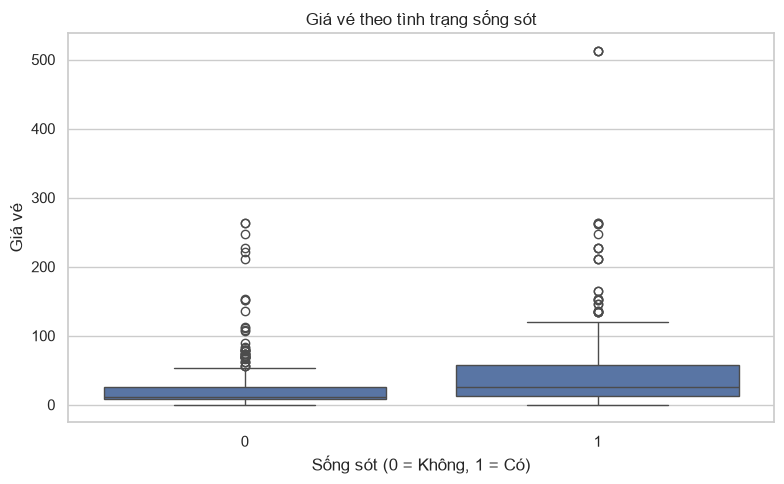

In [22]:
# TODO 5b: Boxplot fare theo survived hoặc pclass
print("Trung vị giá vé theo survived:")
print(df.groupby("survived")["fare"].median())

plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="survived",
    y="fare"
)

plt.title("Giá vé theo tình trạng sống sót")
plt.xlabel("Sống sót (0 = Không, 1 = Có)")
plt.ylabel("Giá vé")
plt.tight_layout()
plt.show()

Tỷ lệ sống sót theo giới tính (%):
sex
female    74.20
male      18.89
Name: survived, dtype: float64


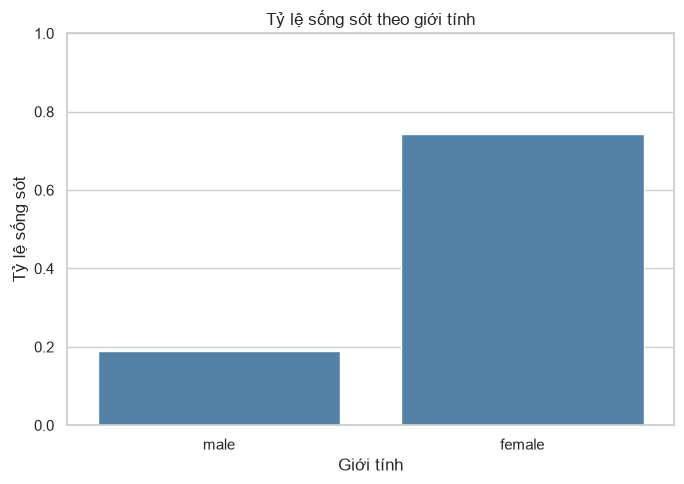


Tỷ lệ sống sót theo hạng vé (%):
pclass
1    62.96
2    47.28
3    24.24
Name: survived, dtype: float64


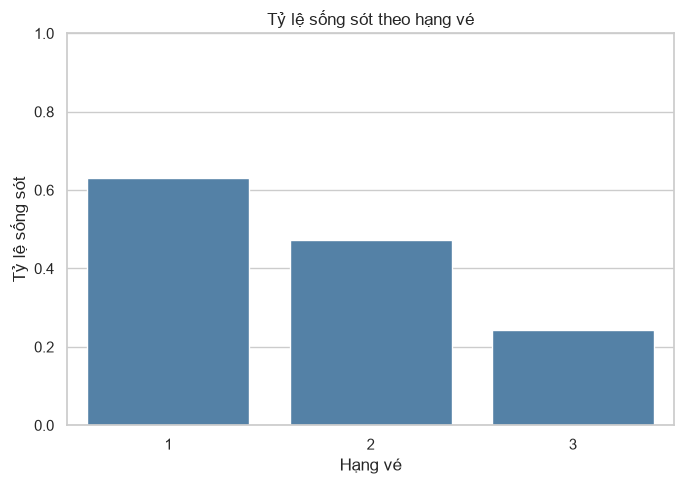

In [23]:
# TODO 5c: Barplot tỷ lệ sống sót theo sex và pclass
# Tính tỷ lệ sống sót theo giới tính
ty_le_theo_sex = (
    df.groupby("sex")["survived"].mean() * 100
).round(2)

print("Tỷ lệ sống sót theo giới tính (%):")
print(ty_le_theo_sex)

plt.figure(figsize=(7, 5))

sns.barplot(
    data=df,
    x="sex",
    y="survived",
    errorbar=None,
    color="steelblue"
)

plt.title("Tỷ lệ sống sót theo giới tính")
plt.xlabel("Giới tính")
plt.ylabel("Tỷ lệ sống sót")
plt.ylim(0, 1)
plt.tight_layout()
plt.show()


# Tính tỷ lệ sống sót theo hạng vé
ty_le_theo_pclass = (
    df.groupby("pclass")["survived"].mean() * 100
).round(2)

print("\nTỷ lệ sống sót theo hạng vé (%):")
print(ty_le_theo_pclass)

plt.figure(figsize=(7, 5))

sns.barplot(
    data=df,
    x="pclass",
    y="survived",
    errorbar=None,
    color="steelblue"
)

plt.title("Tỷ lệ sống sót theo hạng vé")
plt.xlabel("Hạng vé")
plt.ylabel("Tỷ lệ sống sót")
plt.ylim(0, 1)
plt.tight_layout()
plt.show()

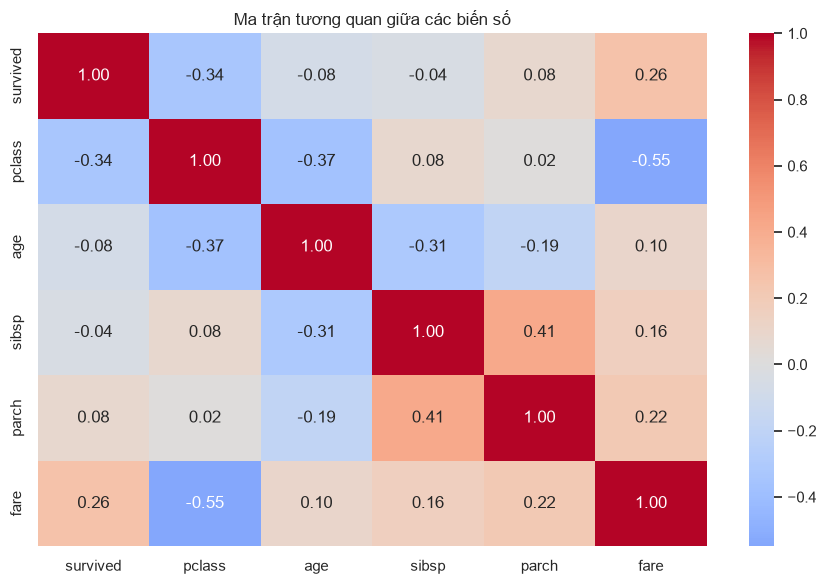

Tương quan của các biến với survived:
pclass   -0.338481
fare      0.257307
parch     0.081629
age      -0.077221
sibsp    -0.035322
Name: survived, dtype: float64


In [24]:
# TODO 5d: Heatmap correlation
corr_matrix = df.select_dtypes(include="number").corr()

plt.figure(figsize=(9, 6))

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

plt.title("Ma trận tương quan giữa các biến số")
plt.tight_layout()
plt.show()

print("Tương quan của các biến với survived:")
print(
    corr_matrix["survived"]
    .drop("survived")
    .sort_values(key=abs, ascending=False)
)

**Nhận xét 5 (viết cho từng biểu đồ ở trên):**

- Histogram: Phân phối age khá gần dạng chuông nhưng hơi lệch phải, với skewness khoảng 0.389. Phần lớn hành khách nằm trong khoảng 20–40 tuổi. Phân phối fare lệch phải rất mạnh, với skewness khoảng 4.787, do phần lớn giá vé ở mức thấp nhưng có một số hành khách mua vé rất đắt.
- Boxplot: Nhóm sống sót có trung vị giá vé khoảng 26, cao hơn nhóm không sống sót có trung vị khoảng 10.5. Cả hai nhóm đều xuất hiện nhiều giá trị vé cao bất thường, đặc biệt là nhóm sống sót.
- Bar survival: Tỷ lệ sống sót của nữ là khoảng 74.20%, cao hơn nhiều so với nam là 18.89%, chênh lệch khoảng 55.31 điểm phần trăm. Hành khách hạng nhất có tỷ lệ sống sót khoảng 62.96%, trong khi hạng ba chỉ khoảng 24.24%, chênh lệch khoảng 38.72 điểm phần trăm.
- Heatmap: Trong các biến số, pclass có tương quan mạnh nhất với survived, với hệ số khoảng -0.338. Dấu âm cho thấy khi giá trị pclass tăng từ 1 lên 3, tức hạng vé thấp hơn, khả năng sống sót có xu hướng giảm. fare có tương quan dương khoảng 0.257 với khả năng sống sót.

---
## Task 6 — Chia tập **TRƯỚC** khi tiền xử lý (chống data leakage)

### Mục đích
Đây là điểm mấu chốt của buổi học. Mọi phép "học tham số" từ dữ liệu (median để điền, min/max/IQR để scale, danh mục để encode) **chỉ được học từ tập train**. Nếu học từ toàn bộ dữ liệu rồi mới chia, thông tin của tập test đã **rò rỉ** — điểm đánh giá sẽ ảo.

⇒ **Vì vậy phải chia tập TRƯỚC**, rồi mới xử lý.

### Yêu cầu
1. Tách `X` (đặc trưng) và `y` (`survived`).
2. Chia **train / validation / test** theo tỷ lệ khoảng **70 / 15 / 15**, có **`stratify=y`** để giữ nguyên tỷ lệ hai lớp.
3. In shape của 3 tập và **tỷ lệ sống sót** trong mỗi tập (để kiểm tra stratify hoạt động).

### Gợi ý
- Dùng `train_test_split` **hai lần**: lần 1 tách test (15%), lần 2 tách val từ phần còn lại.
- `stratify` nhận vào nhãn tương ứng ở mỗi lần chia.

In [25]:
# TODO 6: chia train/val/test có stratify
X = df.drop(columns=["survived"])
y = df["survived"]

# Lần 1: lấy 15% dữ liệu làm tập test
X_tmp, X_test, y_tmp, y_test = train_test_split(
    X,
    y,
    test_size=0.15,
    random_state=42,
    stratify=y
)

# Phần tạm còn 85%.
# Muốn validation chiếm 15% toàn bộ dữ liệu:
# tỷ lệ cần lấy từ tập tạm là 15 / 85
ty_le_val = 0.15 / 0.85

X_train, X_val, y_train, y_val = train_test_split(
    X_tmp,
    y_tmp,
    test_size=ty_le_val,
    random_state=42,
    stratify=y_tmp
)

print(
    "Train/Val/Test:",
    X_train.shape,
    X_val.shape,
    X_test.shape
)

# In tỷ lệ survived từng tập
print(
    "Tỷ lệ sống sót train:",
    round(y_train.mean() * 100, 2),
    "%"
)

print(
    "Tỷ lệ sống sót validation:",
    round(y_val.mean() * 100, 2),
    "%"
)

print(
    "Tỷ lệ sống sót test:",
    round(y_test.mean() * 100, 2),
    "%"
)


Train/Val/Test: (623, 7) (134, 7) (134, 7)
Tỷ lệ sống sót train: 38.36 %
Tỷ lệ sống sót validation: 38.81 %
Tỷ lệ sống sót test: 38.06 %


---
## Task 7 — Xây pipeline tiền xử lý, **fit chỉ trên train**

### Mục đích
Gộp toàn bộ bước tiền xử lý vào một `ColumnTransformer` + `Pipeline`, `fit` **một lần trên `X_train`** rồi `transform` cho val/test. Đây là cách chuẩn để **đảm bảo không leakage** và tái sử dụng được.

### Yêu cầu
Xây `preprocess` gồm:

- **Biến số** (`age`, `sibsp`, `parch`, `fare`): `SimpleImputer(median)` → scaler (chọn `RobustScaler` vì `fare` có outlier, hoặc giải thích lựa chọn khác).
- **Biến phân loại** (`sex`, `embarked`): `SimpleImputer(most_frequent)` → `OneHotEncoder`.
- **Biến thứ tự** (`pclass`): giữ nguyên (`passthrough`) vì đã là số có thứ tự 1 < 2 < 3.

Sau đó: `fit` trên `X_train`, `transform` cho cả ba tập; in shape kết quả và tên cột sau biến đổi.

### Yêu cầu trả lời
- **Trả lời:** giải thích vì sao `fit` chỉ trên train (không phải trên toàn bộ dữ liệu) thì tránh được leakage.

### Gợi ý
- Khung `ColumnTransformer([... ("num", pipe_so, num_cols), ("cat", pipe_cat, cat_cols), ("ord", "passthrough", ord_cols)])`.
- `preprocess.get_feature_names_out()` để xem tên cột sau biến đổi.

In [26]:
num_cols = ["age", "sibsp", "parch", "fare"]
cat_cols = ["sex", "embarked"]
ord_cols = ["pclass"]

# TODO 7: xây pipeline cho biến số và biến phân loại
pipe_so  = Pipeline([
    # ("imputer", ...),
    # ("scaler",  ...),
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", RobustScaler()),
])
pipe_cat = Pipeline([
    # ("imputer", ...),
    # ("onehot",  ...),
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore")),
])

preprocess = ColumnTransformer([
    # ("num", pipe_so,  num_cols),
    # ("cat", pipe_cat, cat_cols),
    # ("ord", "passthrough", ord_cols),
    ("num", pipe_so, num_cols),
    ("cat", pipe_cat, cat_cols),
    ("ord", "passthrough", ord_cols),
])

# preprocess.fit(X_train)               # fit CHỈ trên train
preprocess.fit(X_train)
# X_train_t = preprocess.transform(X_train)
# ... transform cho val, test
# print(X_train_t.shape, list(preprocess.get_feature_names_out()))
X_train_t = preprocess.transform(X_train)
X_val_t = preprocess.transform(X_val)
X_test_t = preprocess.transform(X_test)

print("Shape sau tiền xử lý:")
print("Train:", X_train_t.shape)
print("Validation:", X_val_t.shape)
print("Test:", X_test_t.shape)

print("\nTên các cột sau biến đổi:")
print(list(preprocess.get_feature_names_out()))

Shape sau tiền xử lý:
Train: (623, 10)
Validation: (134, 10)
Test: (134, 10)

Tên các cột sau biến đổi:
['num__age', 'num__sibsp', 'num__parch', 'num__fare', 'cat__sex_female', 'cat__sex_male', 'cat__embarked_C', 'cat__embarked_Q', 'cat__embarked_S', 'ord__pclass']


**Trả lời 7 (vì sao fit chỉ trên train tránh leakage):**

Do Pipeline chỉ được fit trên X_train để median, mode, thông tin scaling và các giá trị phân loại đều được học hoàn toàn từ tập train.

Sau đó, các tham số đã học mới được dùng để transform tập validation và test. Vì vậy, thông tin của validation và test không ảnh hưởng đến quá trình chuẩn bị dữ liệu hoặc quá trình huấn luyện.

Nếu fit trên toàn bộ dữ liệu trước khi chia, median, IQR hoặc danh sách category sẽ chứa thông tin từ tập test. Đây là data leakage và có thể làm kết quả đánh giá tốt hơn thực tế.

---
## Task 8 — Câu hỏi tư duy: chọn metric đánh giá

### Mục đích
Buổi học nhấn mạnh: **không có metric tốt nhất tuyệt đối** — phải chọn theo bài toán và mức mất cân bằng dữ liệu. Bài này không cần code, chỉ cần lập luận.

### Yêu cầu — trả lời ngắn gọn:
1. Biến mục tiêu `survived` có **mất cân bằng** không? (tính tỷ lệ hai lớp để trả lời).
2. Nếu chỉ nhìn **Accuracy**, có thể bị đánh lừa trong trường hợp nào?
3. Với bài toán Titanic, bạn sẽ ưu tiên metric nào (Accuracy / Precision / Recall / F1)? Vì sao?

In [27]:
# TODO 8: tính tỷ lệ hai lớp của 'survived' để hỗ trợ trả lời
so_luong_lop = (
    df["survived"]
    .value_counts()
    .sort_index()
)

ty_le_lop = (
    df["survived"]
    .value_counts(normalize=True)
    .sort_index() * 100
).round(2)

bang_ty_le = pd.DataFrame({
    "Số lượng": so_luong_lop,
    "Tỷ lệ (%)": ty_le_lop
})

bang_ty_le

,Số lượng,Tỷ lệ (%)
survived,,
0,549,61.62
1,342,38.38


**Trả lời 8:**

1. Biến mục tiêu có 549 hành khách không sống sót, chiếm 61.62%, và 342 hành khách sống sót, chiếm 38.38%. Dữ liệu có mất cân bằng nhẹ nhưng chưa phải mất cân bằng nghiêm trọng.
2. Accuracy có thể gây hiểu nhầm khi một lớp chiếm tỷ lệ quá lớn. Ví dụ, nếu 95% hành khách thuộc lớp không sống sót, mô hình luôn dự đoán không sống sót vẫn đạt accuracy 95% dù không nhận diện được bất kỳ người sống sót nào.
3. Với bài toán Titanic, em ưu tiên F1-score cho lớp sống sót vì F1 cân bằng giữa Precision và Recall. Metric này giúp đánh giá mô hình vừa hạn chế dự đoán nhầm một người không sống sót thành sống sót, vừa hạn chế bỏ sót những người thực sự sống sót. Accuracy vẫn có thể được báo cáo thêm vì hai lớp không chênh lệch quá lớn.

---
## Task 9 — Nhận xét tổng hợp về dữ liệu

### Mục đích
Khép lại toàn bộ EDA bằng một bản tóm tắt như một data analyst gửi cho đồng đội: **những gì đáng chú ý nhất** về bộ dữ liệu này.

### Yêu cầu — viết ít nhất 5 gạch đầu dòng, dựa trên **bằng chứng** (số liệu / biểu đồ) ở trên:
- Đặc trưng nào **tương quan mạnh nhất** với khả năng sống sót? (số liệu chứng minh)
- Cột nào **thiếu nhiều nhất** và bạn đã xử lý thế nào?
- Biến mục tiêu có **mất cân bằng** không? ảnh hưởng gì tới việc chọn metric?
- Đặc trưng nào cần **scaling**, đặc trưng nào cần **encoding**? vì sao?
- Một điều bạn thấy **bất ngờ / thú vị** trong dữ liệu.

**Nhận xét tổng hợp của bạn:**

1. Trong các biến số, pclass có tương quan mạnh nhất với khả năng sống sót, với hệ số tương quan khoảng -0.338. Hành khách hạng nhất có tỷ lệ sống sót 62.96%, trong khi hành khách hạng ba chỉ có tỷ lệ sống sót 24.24%.
2. Giới tính tạo ra sự khác biệt rất lớn về khả năng sống sót. Tỷ lệ sống sót của nữ là 74.20%, trong khi tỷ lệ của nam chỉ là 18.89%, chênh lệch khoảng 55.31 điểm phần trăm.
3. Sau khi loại bỏ cột deck, cột thiếu nhiều nhất còn lại là age, thiếu 177 dòng, tương đương 19.87%. Em xử lý bằng cách điền median được học từ tập train. Cột embarked chỉ thiếu 2 dòng, tương đương 0.22%, nên được điền bằng mode của tập train.
4. Biến mục tiêu có 61.62% hành khách không sống sót và 38.38% hành khách sống sót. Đây là mất cân bằng nhẹ, vì vậy không nên chỉ dựa vào Accuracy mà nên xem thêm F1-score, Precision và Recall.
5. Các biến số age, sibsp, parch và fare được điền missing bằng median và scale bằng RobustScaler. Trong đó, fare đặc biệt cần scaling vì có phân phối lệch phải mạnh và có 116 outlier theo phương pháp IQR.
6. Các biến sex và embarked cần One-Hot Encoding vì chúng là dữ liệu phân loại không có thứ tự. pclass được giữ nguyên vì đây là biến thứ tự, trong đó hạng 1, hạng 2 và hạng 3 thể hiện các mức vé khác nhau.
7. Trung vị giá vé của nhóm sống sót là 26, cao hơn nhóm không sống sót có trung vị 10.5. Điều này cho thấy hành khách trả giá vé cao hơn, thường thuộc hạng vé tốt hơn, có khả năng sống sót cao hơn.
8. Điều đáng chú ý nhất là giới tính tạo ra chênh lệch tỷ lệ sống sót lớn hơn rất nhiều so với nhiều đặc trưng số khác. Ngoài ra, giá vé có giá trị lớn nhất lên đến 512.3292, cao hơn rất nhiều so với trung vị 14.4542, cho thấy phân phối giá vé bị lệch phải mạnh.

---
## (Bonus — không bắt buộc) Thử thách nâng cao

Chọn **một** trong các hướng sau nếu bạn muốn thử sức:

1. **Feature engineering:** tạo đặc trưng mới `family_size = sibsp + parch + 1`, hoặc trích `title` (Mr/Mrs/Miss...) từ tên (nếu dùng bản có cột `name`). Kiểm tra tương quan với `survived`.
2. **So sánh scaler:** vẽ phân phối `fare` trước và sau khi áp `StandardScaler`, `MinMaxScaler`, `RobustScaler`. Nhận xét scaler nào phù hợp nhất với dữ liệu lệch + có outlier.
3. **Bẫy KNN:** thử `KNNImputer` để điền `age` **khi chưa scale** và **sau khi đã scale** `fare`. Quan sát kết quả có khác nhau không, và giải thích tại sao (gợi ý: khoảng cách Euclid bị chi phối bởi cột thang đo lớn).

Thống kê family_size:
count    891.000000
mean       1.904602
std        1.613459
min        1.000000
25%        1.000000
50%        1.000000
75%        2.000000
max       11.000000
Name: family_size, dtype: float64

Tỷ lệ sống sót theo family_size:
             count   mean
family_size              
1              537  30.35
2              161  55.28
3              102  57.84
4               29  72.41
5               15  20.00
6               22  13.64
7               12  33.33
8                6   0.00
11               7   0.00


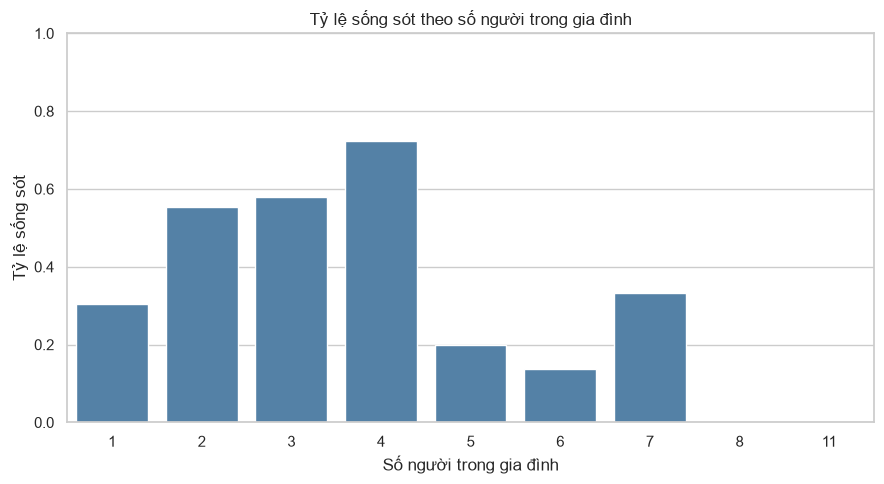

In [28]:
# (tùy chọn) code cho phần Bonus
# Tạo bản sao để không làm thay đổi dataframe gốc
df_bonus = df.copy()

# Tổng số người trong gia đình gồm:
# bản thân hành khách + anh chị em/vợ chồng + cha mẹ/con cái
df_bonus["family_size"] = (
    df_bonus["sibsp"]
    + df_bonus["parch"]
    + 1
)

print("Thống kê family_size:")
print(df_bonus["family_size"].describe())

print("\nTỷ lệ sống sót theo family_size:")
family_survival = df_bonus.groupby("family_size")["survived"].agg([
    "count",
    "mean"
])

family_survival["mean"] = (
    family_survival["mean"] * 100
).round(2)

print(family_survival)

plt.figure(figsize=(9, 5))

sns.barplot(
    data=df_bonus,
    x="family_size",
    y="survived",
    errorbar=None,
    color="steelblue"
)

plt.title("Tỷ lệ sống sót theo số người trong gia đình")
plt.xlabel("Số người trong gia đình")
plt.ylabel("Tỷ lệ sống sót")
plt.ylim(0, 1)
plt.tight_layout()
plt.show()

---
## Bảng tự kiểm trước khi nộp

- [ ] Notebook chạy **Restart & Run All** không lỗi.
- [ ] Đã bỏ các cột rò rỉ/dư thừa (Task 1) và giải thích được vì sao.
- [ ] Mỗi biểu đồ (Task 5) đều có **nhận xét**.
- [ ] Đã **chia tập trước**, tiền xử lý **fit chỉ trên train** (Task 6–7).
- [ ] Đã trả lời tất cả các phần *"Trả lời:"*.
- [ ] Nhận xét tổng hợp (Task 9) có **ít nhất 5 ý** dựa trên bằng chứng.
- [ ] Đã push lên **repo cá nhân trên GitHub**.
